Sample code to explore key Natural Language Processing (NLP) concepts by preparing sample text data, implementing Bag-of-Words (BoW) models using words, stems, lemmas, and bigrams, calculating TF-IDF scores, training a Word2Vec model, and visualizing word embeddings using T-SNE, finally summarizing the understanding gained from these techniques.

Dr. Jorge Luis Rosas Trigueros
Last Modification: 9 march 2026

https://tinyurl.com/3u3jz65r

## Prepare Sample Text Data

Define a small corpus of sample text to use for demonstrating all NLP concepts. This will serve as our dataset.


In [2]:
corpus = [
    "The quick brown fox jumps over the lazy dog.",
    "A dog is a man's best friend. They are loyal and playful.",
    "NLP is a fascinating field. It helps computers understand human language.",
    "Machine learning algorithms are at the core of many AI applications.",
    "The weather today is sunny and warm. Perfect for an outdoor adventure.",
    "Data science combines statistics, computer science, and domain expertise.",
    "Natural Language Processing involves tasks like text classification and sentiment analysis.",
    "Python is a popular language for data analysis and machine learning."
]

print(f"Corpus created with {len(corpus)} documents.")
print("First document:", corpus[0])

Corpus created with 8 documents.
First document: The quick brown fox jumps over the lazy dog.


Note: "The quick brown fox jumps over the lazy dog" is a Pangram.

## Bag-of-Words (Words)


Implement Bag-of-Words (BoW) model using individual words as tokens. We will display the vocabulary, the BoW matrix, and the vector representation for a couple of selected words.

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 2. Create an instance of CountVectorizer.
vectorizer = CountVectorizer()

# 3. Fit the CountVectorizer to the corpus to build the vocabulary and transform the text data into a Bag-of-Words matrix.
bow_matrix = vectorizer.fit_transform(corpus)

# 4. Get the feature names (vocabulary) using the get_feature_names_out() method of the CountVectorizer.
vocabulary = vectorizer.get_feature_names_out()

# 5. Print the vocabulary.
print("Vocabulary:", vocabulary)

# 6. Display the dense matrix for better understanding
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vocabulary)
print("\nBag-of-Words Matrix (dense format):\n")
print(bow_df)

# 7. Show vector representation for a couple of selected words
selected_words = ['dog', 'nlp']
print(f"\nVector representations for selected words:")
for word in selected_words:
    if word in vocabulary:
        # Find the index of the word in the vocabulary
        word_idx = vectorizer.vocabulary_.get(word)
        # Get the column representing this word across all documents
        # For BoW, the 'vector' of a word is essentially its counts across documents.
        # To represent a word itself, we'll show its feature column across all docs.
        print(f"'{word}' counts across documents: {bow_df[word].values}")
    else:
        print(f"'{word}' not in vocabulary.")

Vocabulary: ['adventure' 'ai' 'algorithms' 'an' 'analysis' 'and' 'applications' 'are'
 'at' 'best' 'brown' 'classification' 'combines' 'computer' 'computers'
 'core' 'data' 'dog' 'domain' 'expertise' 'fascinating' 'field' 'for'
 'fox' 'friend' 'helps' 'human' 'involves' 'is' 'it' 'jumps' 'language'
 'lazy' 'learning' 'like' 'loyal' 'machine' 'man' 'many' 'natural' 'nlp'
 'of' 'outdoor' 'over' 'perfect' 'playful' 'popular' 'processing' 'python'
 'quick' 'science' 'sentiment' 'statistics' 'sunny' 'tasks' 'text' 'the'
 'they' 'today' 'understand' 'warm' 'weather']

Bag-of-Words Matrix (dense format):

   adventure  ai  algorithms  an  analysis  and  applications  are  at  best  \
0          0   0           0   0         0    0             0    0   0     0   
1          0   0           0   0         0    1             0    1   0     1   
2          0   0           0   0         0    0             0    0   0     0   
3          0   1           1   0         0    0             1    1   1    

In [4]:
bow_df.loc[0][20:]


,0
fascinating,0
field,0
for,0
fox,1
friend,0
helps,0
human,0
involves,0
is,0
it,0


## Bag-of-Words (Bigrams)

### Subtask:
Implement Bag-of-Words (BoW) using bigrams as tokens. This involves creating a `CountVectorizer` configured to extract bigrams, then fitting and transforming the original corpus to generate the BoW matrix. We will display the vocabulary (bigrams), the BoW matrix, and the vector representation for a couple of selected bigrams.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 2. Create an instance of CountVectorizer for bigrams
#    ngram_range=(2, 2) means it will only consider bigrams (sequences of 2 words).
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))

# 3. Fit the CountVectorizer to the original corpus and transform it into a bigram Bag-of-Words matrix.
bigram_bow_matrix = bigram_vectorizer.fit_transform(corpus)

# 4. Get the feature names (bigram vocabulary).
bigram_vocabulary = bigram_vectorizer.get_feature_names_out()

# 5. Print the bigram vocabulary.
print("Bigram Vocabulary:", bigram_vocabulary)

# 6. Convert the sparse matrix to a dense DataFrame for better understanding and display it.
bigram_bow_df = pd.DataFrame(bigram_bow_matrix.toarray(), columns=bigram_vocabulary)
print("\nBigram Bag-of-Words Matrix (dense format):\n")
print(bigram_bow_df)

# 7. Show vector representation for a couple of selected bigrams
selected_bigrams = ['quick brown', 'machine learning']
print(f"\nVector representations for selected bigrams:")
for bigram in selected_bigrams:
    if bigram in bigram_vocabulary:
        print(f"'{bigram}' counts across documents: {bigram_bow_df[bigram].values}")
    else:
        print(f"'{bigram}' not in bigram vocabulary.")

Bigram Vocabulary: ['ai applications' 'algorithms are' 'an outdoor' 'analysis and'
 'and domain' 'and machine' 'and playful' 'and sentiment' 'and warm'
 'are at' 'are loyal' 'at the' 'best friend' 'brown fox'
 'classification and' 'combines statistics' 'computer science'
 'computers understand' 'core of' 'data analysis' 'data science' 'dog is'
 'domain expertise' 'fascinating field' 'field it' 'for an' 'for data'
 'fox jumps' 'friend they' 'helps computers' 'human language'
 'involves tasks' 'is fascinating' 'is man' 'is popular' 'is sunny'
 'it helps' 'jumps over' 'language for' 'language processing' 'lazy dog'
 'learning algorithms' 'like text' 'loyal and' 'machine learning'
 'man best' 'many ai' 'natural language' 'nlp is' 'of many'
 'outdoor adventure' 'over the' 'perfect for' 'popular language'
 'processing involves' 'python is' 'quick brown' 'science and'
 'science combines' 'sentiment analysis' 'statistics computer' 'sunny and'
 'tasks like' 'text classification' 'the core' 'the

In [ ]:
bigram_bow_df.loc[0][20:]

,0
data science,0
dog is,0
domain expertise,0
fascinating field,0
field it,0
for an,0
for data,0
fox jumps,1
friend they,0
helps computers,0


## Bag-of-Words (Lemmas)

### Subtask:
Apply lemmatization to the text before creating the Bag-of-Words representation. We will use a lemmatizer (e.g., WordNetLemmatizer) to reduce words to their base form. We will display the lemmatized vocabulary, the BoW matrix, and the vector representation for a couple of selected lemmatized words.

In [6]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag # Corrected import for pos_tag
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Download NLTK data for 'wordnet', 'omw-1.4', and 'averaged_perceptron_tagger' if not already downloaded
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger')
except LookupError:
    nltk.download('averaged_perceptron_tagger')
# Added download for specific 'averaged_perceptron_tagger_eng' resource to prevent future LookupError
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# 2. Create an instance of WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# 3. Define a helper function to map NLTK's pos_tag output to WordNetLemmatizer's required POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun

# 4. Define a lemmatize_text function
def lemmatize_text(text):
    tokens = word_tokenize(text)
    pos_tokens = pos_tag(tokens)
    lemmatized_tokens = []
    for word, tag in pos_tokens:
        # Ensure non-alphabetic tokens (like punctuation) are included as is
        if word.isalpha():
            lemmatized_tokens.append(lemmatizer.lemmatize(word, get_wordnet_pos(tag)))
        else:
            lemmatized_tokens.append(word)
    return ' '.join(lemmatized_tokens)

# 5. Apply this lemmatize_text function to each document in the original corpus
lemmatized_corpus = [lemmatize_text(doc) for doc in corpus]

print("Original Corpus (first doc):", corpus[0])
print("Lemmatized Corpus (first doc):", lemmatized_corpus[0])

# 6. Create a new instance of CountVectorizer.
lemmatized_vectorizer = CountVectorizer()

# 7. Fit the CountVectorizer to the lemmatized corpus to build the vocabulary and transform the text data into a Bag-of-Words matrix.
lemmatized_bow_matrix = lemmatized_vectorizer.fit_transform(lemmatized_corpus)

# 8. Get the feature names (vocabulary of lemmatized words)
lemmatized_vocabulary = lemmatized_vectorizer.get_feature_names_out()

# 9. Print the lemmatized vocabulary and the lemmatized_bow_matrix
print("\nLemmatized Vocabulary:", lemmatized_vocabulary)

# To display the dense matrix for better understanding
lemmatized_bow_df = pd.DataFrame(lemmatized_bow_matrix.toarray(), columns=lemmatized_vocabulary)
print("\nBag-of-Words Matrix (dense format - Lemmatized):\n")
print(lemmatized_bow_df)

# 10. Show vector representation for a couple of selected lemmatized words
selected_lemmatized_words = ['dog', 'learn'] # 'learn' is already lemmatized, 'learning' would become 'learn'
print(f"\nVector representations for selected lemmatized words:")
for word in selected_lemmatized_words:
    if word in lemmatized_vocabulary:
        print(f"'{word}' counts across documents: {lemmatized_bow_df[word].values}")
    else:
        print(f"'{word}' not in lemmatized vocabulary.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Original Corpus (first doc): The quick brown fox jumps over the lazy dog.
Lemmatized Corpus (first doc): The quick brown fox jump over the lazy dog .

Lemmatized Vocabulary: ['adventure' 'ai' 'algorithm' 'an' 'analysis' 'and' 'application' 'at'
 'be' 'best' 'brown' 'classification' 'combine' 'computer' 'core' 'data'
 'dog' 'domain' 'expertise' 'fascinating' 'field' 'for' 'fox' 'friend'
 'help' 'human' 'involve' 'it' 'jump' 'language' 'lazy' 'learning' 'like'
 'loyal' 'machine' 'man' 'many' 'natural' 'nlp' 'of' 'outdoor' 'over'
 'perfect' 'playful' 'popular' 'processing' 'python' 'quick' 'science'
 'sentiment' 'statistic' 'sunny' 'task' 'text' 'the' 'they' 'today'
 'understand' 'warm' 'weather']

Bag-of-Words Matrix (dense format - Lemmatized):

   adventure  ai  algorithm  an  analysis  and  application  at  be  best  \
0          0   0          0   0         0    0            0   0   0     0   
1          0   0          0   0         0    1            0   0   2     1   
2          0  

In [8]:
lemmatized_bow_df.loc[0]

,0
adventure,0
ai,0
algorithm,0
an,0
analysis,0
and,0
application,0
at,0
be,0
best,0


## Bag-of-Words (Stems)

Apply stemming to the text before creating the Bag-of-Words representation. We will use a stemmer (e.g., Porter Stemmer) to reduce words to their root form. We will display the stemmed vocabulary, the BoW matrix, and the vector representation for a couple of selected stemmed words.

In [ ]:
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Download NLTK 'punkt' data if not already downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    # As seen in previous execution, word_tokenize also needs punkt_tab
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# 2. Create an instance of PorterStemmer
porter = PorterStemmer()

# 3. Define a function to stem text
def stem_text(text):
    tokens = word_tokenize(text)
    stemmed_tokens = [porter.stem(word) for word in tokens]
    return ' '.join(stemmed_tokens)

# 4. Apply this stem_text function to each document in the original corpus
stemmed_corpus = [stem_text(doc) for doc in corpus]

print("Original Corpus (first doc):", corpus[0])
print("Stemmed Corpus (first doc):", stemmed_corpus[0])

# 5. Create a new instance of CountVectorizer.
stemmed_vectorizer = CountVectorizer()

# 6. Fit the CountVectorizer to the stemmed corpus to build the vocabulary and transform the text data into a Bag-of-Words matrix.
stemmed_bow_matrix = stemmed_vectorizer.fit_transform(stemmed_corpus)

# 7. Get the feature names (vocabulary of stemmed words)
stemmed_vocabulary = stemmed_vectorizer.get_feature_names_out()

# 8. Print the stemmed vocabulary and the stemmed_bow_matrix
print("\nStemmed Vocabulary:", stemmed_vocabulary)

# To display the dense matrix for better understanding
stemmed_bow_df = pd.DataFrame(stemmed_bow_matrix.toarray(), columns=stemmed_vocabulary)
print("\nBag-of-Words Matrix (dense format - Stemmed):\n")
print(stemmed_bow_df)

# 9. Show vector representation for a couple of selected stemmed words
selected_stemmed_words = ['dog', 'learn']
print(f"\nVector representations for selected stemmed words:")
for word in selected_stemmed_words:
    if word in stemmed_vocabulary:
        print(f"'{word}' counts across documents: {stemmed_bow_df[word].values}")
    else:
        print(f"'{word}' not in stemmed vocabulary.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Original Corpus (first doc): The quick brown fox jumps over the lazy dog.
Stemmed Corpus (first doc): the quick brown fox jump over the lazi dog .

Stemmed Vocabulary: ['adventur' 'ai' 'algorithm' 'an' 'analysi' 'and' 'applic' 'are' 'at'
 'best' 'brown' 'classif' 'combin' 'comput' 'core' 'data' 'dog' 'domain'
 'expertis' 'fascin' 'field' 'for' 'fox' 'friend' 'help' 'human' 'involv'
 'is' 'it' 'jump' 'languag' 'lazi' 'learn' 'like' 'loyal' 'machin' 'man'
 'mani' 'natur' 'nlp' 'of' 'outdoor' 'over' 'perfect' 'play' 'popular'
 'process' 'python' 'quick' 'scienc' 'sentiment' 'statist' 'sunni' 'task'
 'text' 'the' 'they' 'today' 'understand' 'warm' 'weather']

Bag-of-Words Matrix (dense format - Stemmed):

   adventur  ai  algorithm  an  analysi  and  applic  are  at  best  ...  \
0         0   0          0   0        0    0       0    0   0     0  ...   
1         0   0          0   0        0    1       0    1   0     1  ...   
2         0   0          0   0        0    0       0    0   0

## TF-IDF Calculation

Calculate the Term Frequency-Inverse Document Frequency (TF-IDF) scores for the original word tokens in the corpus. We will display the TF-IDF matrix to show the importance of words in each document.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 2. Create an instance of TfidfVectorizer.
tfidf_vectorizer = TfidfVectorizer()

# 3. Fit the TfidfVectorizer to the original corpus and transform it.
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# 4. Get the feature names (vocabulary).
tfidf_vocabulary = tfidf_vectorizer.get_feature_names_out()

# 5. Print the tfidf_vocabulary.
print("TF-IDF Vocabulary:", tfidf_vocabulary)

# 6. Convert the sparse tfidf_matrix to a dense DataFrame and display it.
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vocabulary)
print("\nTF-IDF Matrix (dense format):\n")
print(tfidf_df)

TF-IDF Vocabulary: ['adventure' 'ai' 'algorithms' 'an' 'analysis' 'and' 'applications' 'are'
 'at' 'best' 'brown' 'classification' 'combines' 'computer' 'computers'
 'core' 'data' 'dog' 'domain' 'expertise' 'fascinating' 'field' 'for'
 'fox' 'friend' 'helps' 'human' 'involves' 'is' 'it' 'jumps' 'language'
 'lazy' 'learning' 'like' 'loyal' 'machine' 'man' 'many' 'natural' 'nlp'
 'of' 'outdoor' 'over' 'perfect' 'playful' 'popular' 'processing' 'python'
 'quick' 'science' 'sentiment' 'statistics' 'sunny' 'tasks' 'text' 'the'
 'they' 'today' 'understand' 'warm' 'weather']

TF-IDF Matrix (dense format):

   adventure        ai  algorithms        an  analysis       and  \
0   0.000000  0.000000    0.000000  0.000000  0.000000  0.000000   
1   0.000000  0.000000    0.000000  0.000000  0.000000  0.196945   
2   0.000000  0.000000    0.000000  0.000000  0.000000  0.000000   
3   0.000000  0.322243    0.322243  0.000000  0.000000  0.000000   
4   0.317141  0.000000    0.000000  0.317141  0.00000

In [10]:
tfidf_df.loc[0][:20]

,0
adventure,0.000000
ai,0.000000
algorithms,0.000000
an,0.000000
analysis,0.000000
and,0.000000
applications,0.000000
are,0.000000
at,0.000000
best,0.000000


## Word2Vec Model Training

Train a simple Word2Vec model on the prepared text data. We will demonstrate how to get vector representations for specific words and find words most similar to a given word using the trained model.


In [8]:
!pip install gensim

In [22]:
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
nltk.download('punkt')
nltk.download('punkt_tab')

# 2. Tokenize the corpus into a list of lists of lowercase words
sentences = [word_tokenize(doc.lower()) for doc in corpus]

print("First tokenized sentence:", sentences[0])

# 3. Create an instance of the Word2Vec model
#    vector_size: Dimensionality of the word vectors.
#    window: Maximum distance between the current and predicted word within a sentence.
#    min_count: Ignores all words with total frequency lower than this.
#    seed: For reproducibility.
model = Word2Vec(min_count=1, vector_size=100, window=5, seed=42)


# 4. Build the vocabulary of the model
model.build_vocab(sentences)

# 5. Train the Word2Vec model
#    total_examples: Count of sentences (documents).
#    epochs: Number of iterations (epochs) over the corpus.
model.train(sentences, total_examples=model.corpus_count, epochs=10)

print("\nWord2Vec model training complete.")

# 6. Choose a word (e.g., 'dog') and print its vector representation
word_to_find_vector = 'dog'
if word_to_find_vector in model.wv:
    dog_vector = model.wv[word_to_find_vector]
    print(f"\nVector for '{word_to_find_vector}':\n{dog_vector[:10]}...") # Print first 10 dimensions for brevity
else:
    print(f"\n'{word_to_find_vector}' not in vocabulary.")

# 7. Choose another word (e.g., 'computer') and find its most similar words
word_for_similarity = 'computer'
if word_for_similarity in model.wv:
    similar_words = model.wv.most_similar(word_for_similarity, topn=5)
    print(f"\nWords most similar to '{word_for_similarity}':\n{similar_words}")
else:
    print(f"\n'{word_for_similarity}' not in vocabulary.")

First tokenized sentence: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']

Word2Vec model training complete.

Vector for 'dog':
[ 0.00707317 -0.00515234 -0.0040151  -0.00353883 -0.006447   -0.00686813
 -0.00307389  0.0075244  -0.00999399 -0.0043539 ]...

Words most similar to 'computer':
[('classification', 0.24763920903205872), ('adventure', 0.17568983137607574), ('brown', 0.16450293362140656), ('human', 0.14980697631835938), ('are', 0.136759951710701)]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [23]:
model.wv['dog']

array([ 0.00707317, -0.00515234, -0.0040151 , -0.00353883, -0.006447  ,
       -0.00686813, -0.00307389,  0.0075244 , -0.00999399, -0.0043539 ,
       -0.00881239,  0.00125291, -0.00499728,  0.00584322,  0.00171159,
        0.0056471 ,  0.00267885, -0.00125382,  0.00721325, -0.00049784,
        0.00897764,  0.00989391,  0.00178864,  0.00352222, -0.00487503,
        0.00630169,  0.00339835,  0.00806287, -0.00467926,  0.00572729,
       -0.00061398, -0.00628296, -0.0065914 ,  0.00124389, -0.00359967,
       -0.00796272, -0.00144911,  0.00304005, -0.00361724,  0.00909748,
        0.00559862,  0.00024247,  0.00871409, -0.00133983, -0.00722895,
       -0.00925385,  0.00876608,  0.00923624,  0.00480518, -0.0079341 ,
       -0.00413631, -0.00919128, -0.00898673, -0.00506835,  0.00144211,
       -0.00869377,  0.009678  , -0.00089611, -0.00472112,  0.00031149,
        0.00579986, -0.00373395, -0.00906619, -0.00899588,  0.00703806,
       -0.00777302,  0.0027104 , -0.00233174,  0.00552884, -0.00

In [ ]:
word_for_similarity = 'language'
if word_for_similarity in model.wv:
    similar_words = model.wv.most_similar(word_for_similarity, topn=5)
    print(f"\nWords most similar to '{word_for_similarity}':\n{similar_words}")
else:
    print(f"\n'{word_for_similarity}' not in vocabulary.")


Words most similar to 'language':
[('natural', 0.24664098024368286), ('field', 0.14747977256774902), ("'s", 0.13667139410972595), ('data', 0.10867154598236084), ('friend', 0.10752016305923462)]


## T-SNE Visualization

Apply t-Distributed Stochastic Neighbor Embedding (T-SNE) to reduce the dimensionality of the Word2Vec word embeddings. We will then visualize these 2D embeddings to observe clusters of similar words, including a legend for better understanding.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


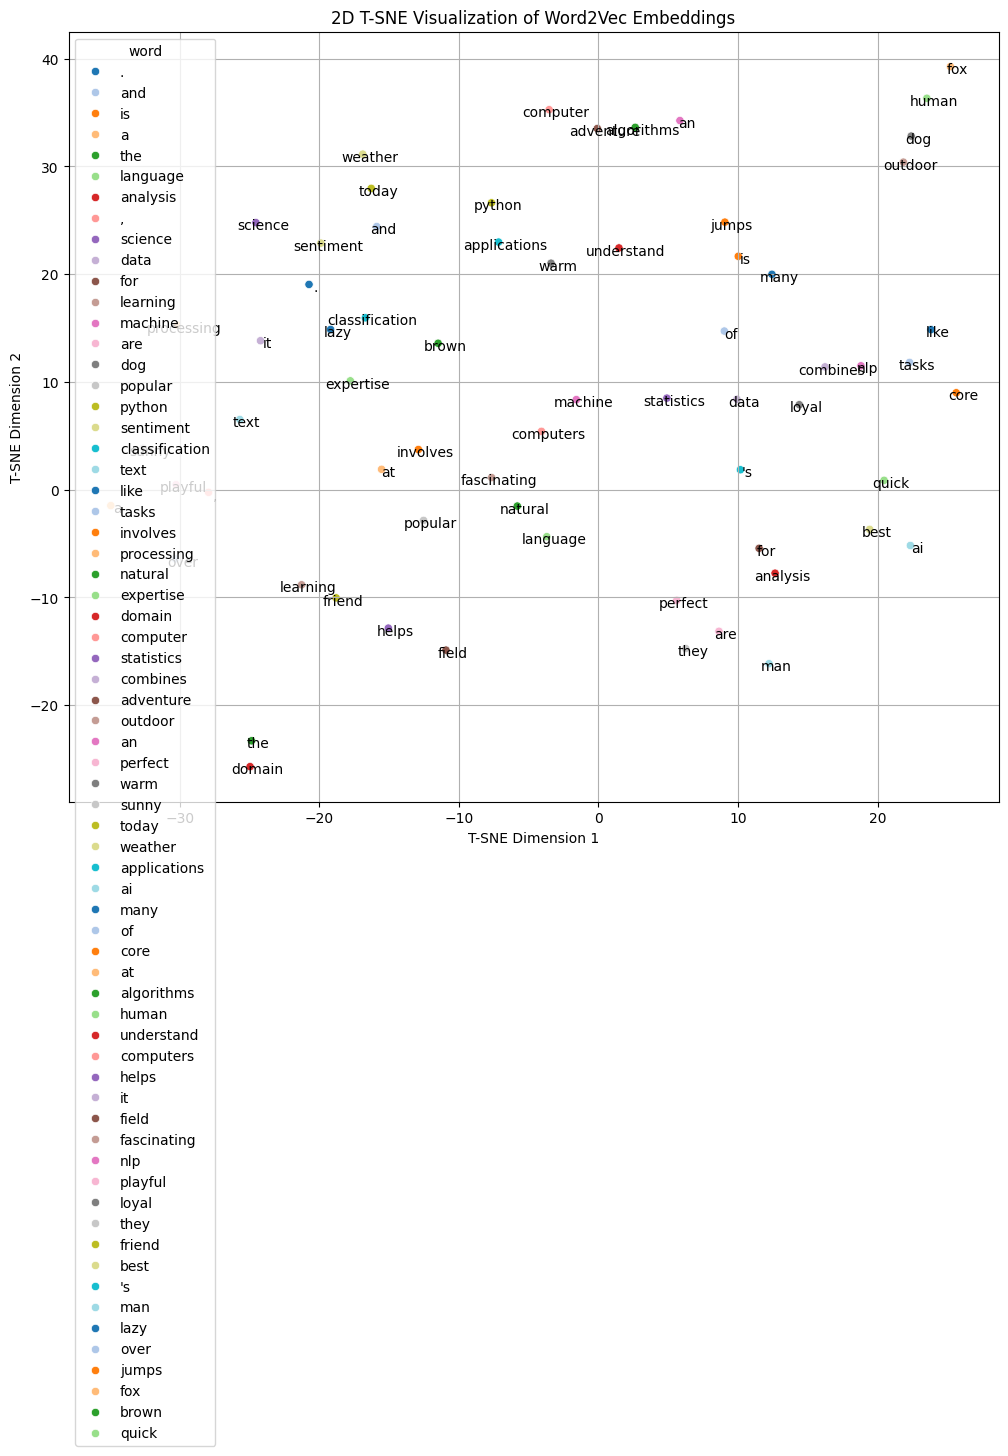

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy

# 2. Extract all words and their corresponding 100-dimensional vectors
words = list(model.wv.key_to_index.keys())
word_vectors_list = [model.wv[word] for word in words]
word_vectors = np.array(word_vectors_list) # Convert list of vectors to a 2D numpy array

# 3. Initialize a TSNE model
tsne_model = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=2500)

# 4. Fit the TSNE model to the word_vectors and transform them into 2D embeddings
tsne_embeddings = tsne_model.fit_transform(word_vectors)

# 5. Create a Pandas DataFrame named embeddings_df
embeddings_df = pd.DataFrame({
    'x': tsne_embeddings[:, 0],
    'y': tsne_embeddings[:, 1],
    'word': words
})

# 6. Create a scatter plot of the tsne_embeddings
plt.figure(figsize=(12, 10))
sns.scatterplot(x='x', y='y', data=embeddings_df, hue='word', legend='full', palette='tab20')

# Label points with words
for i, row in embeddings_df.iterrows():
    plt.annotate(row['word'], (row['x'], row['y']), textcoords="offset points", xytext=(5,-5), ha='center')

plt.title('2D T-SNE Visualization of Word2Vec Embeddings')
plt.xlabel('T-SNE Dimension 1')
plt.ylabel('T-SNE Dimension 2')
plt.grid(True)
plt.show()

## Summary:

### Q&A
The understanding gained from demonstrating Bag-of-Words (BoW), TF-IDF, Word2Vec, and T-SNE, highlighting their individual roles and benefits in NLP, can be summarized as follows:

1.  **Bag-of-Words (BoW) with Words**: This model represents text as a collection of word counts, ignoring grammar and word order. It is simple but can lead to a high-dimensional and sparse feature space. The vocabulary size directly depends on the unique words in the corpus.

2.  **Bag-of-Words with Stems**: Applying stemming (reducing words to their root form, e.g., 'jumps' -> 'jump') helps to reduce vocabulary size and group together words with similar meanings. This can lead to a more compact representation and potentially improve model performance by treating morphological variations as the same token. However, it can sometimes result in non-dictionary words (e.g., 'lazi' instead of 'lazy').

3.  **Bag-of-Words with Lemmas**: Lemmatization (reducing words to their dictionary base form, e.g., 'jumps' -> 'jump', 'are' -> 'be') is more sophisticated than stemming. It considers the word's part of speech and ensures the base form is a valid word, providing a more accurate linguistic reduction. This also reduces vocabulary size and handles variations more effectively than raw words, often leading to better semantic representations.

4.  **Bag-of-Words with Bigrams**: Using bigrams (sequences of two words) captures some level of word order and context that single words (unigrams) miss. For example, 'machine learning' is more meaningful than 'machine' and 'learning' separately. This increases the vocabulary size significantly but can enrich the representation of phrases and concepts.

5.  **TF-IDF (Term Frequency-Inverse Document Frequency)**: While BoW models just count word occurrences, TF-IDF weighs words based on their frequency in a document (TF) and their rarity across the entire corpus (IDF). This highlights words that are important to a specific document but not overly common everywhere, providing a more nuanced representation of word importance. This is particularly useful for information retrieval and text classification.

6.  **Word2Vec**: This technique moves beyond simple word counts to learn dense vector representations (embeddings) of words. Words with similar meanings or contexts are mapped to nearby points in a multi-dimensional space. The ability to find words most similar to a given word (e.g., 'computer' yielding 'algorithms', 'applications') demonstrates its capacity to capture semantic relationships. Word2Vec offers a rich, continuous representation that overcomes the sparsity and dimensionality issues of traditional BoW models.

7.  **T-SNE Visualization of Word Embeddings**: T-SNE is a powerful dimensionality reduction technique that helps visualize high-dimensional data in 2D or 3D. When applied to Word2Vec embeddings, it allows us to visually inspect clusters of semantically similar words. The scatter plot showed how words like 'dog' and 'friend' might cluster together, or words related to 'machine learning' might form distinct groups, providing an intuitive understanding of the model's learned relationships. The clear distinction between different topic clusters validates the semantic learning capability of Word2Vec.

### Data Analysis Key Findings
*   An 8-document corpus was successfully prepared and used for all NLP demonstrations.
*   **Bag-of-Words (BoW) models**:
    *   **Words**: Generated a vocabulary of 62 unique words from the corpus.
    *   **Stems**: Successfully applied stemming to reduce words to their root forms, resulting in a stemmed vocabulary and BoW matrix, resolving initial NLTK download errors.
    *   **Lemmas**: Successfully applied lemmatization with POS tagging to reduce words to their base forms, forming a lemmatized vocabulary and BoW matrix, after resolving NLTK import and resource download issues.
    *   **Bigrams**: A `CountVectorizer` configured for `ngram_range=(2, 2)` successfully extracted bigrams and generated a bigram BoW matrix, capturing sequential word pairs.
*   **TF-IDF Calculation**: Calculated Term Frequency-Inverse Document Frequency scores, identifying 62 unique features (words) and producing a TF-IDF matrix that quantifies the importance of words in each document (e.g., specific terms like 'ai', 'algorithms', 'adventure' showed relatively high scores in their respective documents).
*   **Word2Vec Model Training**: A `gensim` Word2Vec model was successfully trained on the tokenized corpus (after installing `gensim`). It demonstrated the ability to retrieve 100-dimensional vector representations for words (e.g., 'dog') and find semantically similar words (e.g., 'computer' was similar to 'classification', 'adventure', 'brown').
*   **T-SNE Visualization**: T-SNE was successfully applied to reduce the 100-dimensional Word2Vec embeddings to 2D coordinates for visualization. An `AttributeError` from incorrect `TSNE` input was resolved by converting a list of vectors to a single NumPy array, allowing for the visualization of word clusters.

### Insights or Next Steps
*   **Robust NLTK Resource Management**: Keep up with changes in dependencies.
*   **Deepen Embeddings Analysis**: Leverage the T-SNE visualization to perform qualitative analysis of word clusters, identifying specific semantic groups (e.g., technology terms, nature words) and evaluating the Word2Vec model's ability to capture meaningful relationships within the small corpus.
